<a href="https://colab.research.google.com/github/melypadillareyes15-cell/Procesamiento-Digital-de-Imagenes/blob/main/Copia_de_Analisis_imagen_grises_ultima_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de imagen en escala de grises


## 1. Importar librerías

En esta parte se importan las librerías necesarias. `cv2` se utiliza para leer y transformar la imagen, mientras que `matplotlib` permite visualizar la imagen y graficar su histograma.

In [10]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

## 2. Cargar la imagen

Aquí se sube la imagen al notebook.

In [11]:
from google.colab import files

uploaded = files.upload()

Saving ave.jpg to ave (1).jpg


## 3. Leer y mostrar la imagen original

Se lee la imagen con `cv2.imread()`. Como OpenCV carga las imágenes en formato BGR, se convierte a RGB para que los colores se visualicen correctamente con `matplotlib`.

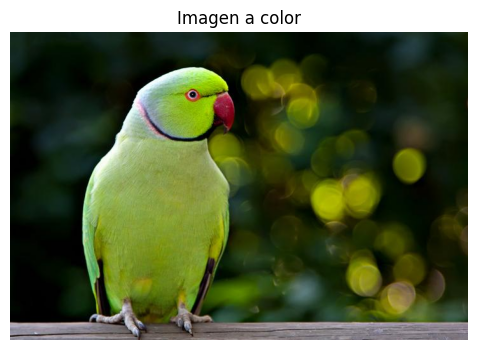

In [12]:
imagen = cv2.imread('ave.jpg')

if imagen is None:
    raise FileNotFoundError("No se encontró la imagen. Asegúrate de subir un archivo llamado ave.jpg")

imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,4))
plt.imshow(imagen_rgb)
plt.title('Imagen a color')
plt.axis('off')
plt.show()

## 4. Convertir la imagen a escala de grises

En esta sección se convierte la imagen a escala de grises. Esto permite trabajar con una sola intensidad por píxel, donde los valores cercanos a 0 representan tonos oscuros y los valores cercanos a 255 representan tonos claros.

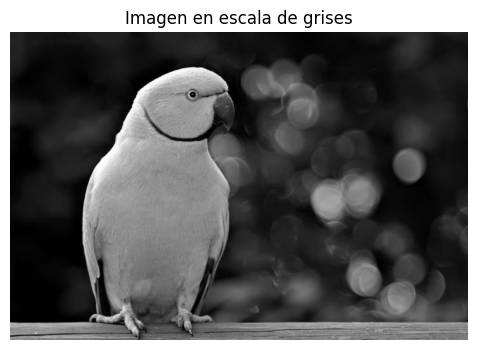

In [13]:
imagen_gris = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(6,4))
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen en escala de grises')
plt.axis('off')
plt.show()

## 5. Calcular el histograma con `cv2.calcHist()`

El histograma permite observar cuántos píxeles hay en cada nivel de intensidad. Con `cv2.calcHist()` se calcula la frecuencia de los valores de gris entre 0 y 255.

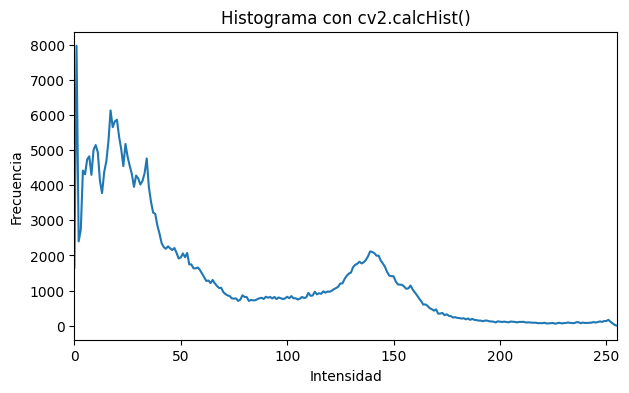

In [14]:
histograma_cv2 = cv2.calcHist([imagen_gris], [0], None, [256], [0, 256])

plt.figure(figsize=(7,4))
plt.plot(histograma_cv2)
plt.title('Histograma con cv2.calcHist()')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.xlim([0, 255])
plt.show()

## 6. Graficar el histograma con `plt.hist()`

También se puede graficar el histograma usando `plt.hist()`. Para esto se convierten todos los píxeles de la imagen en una sola lista de valores con `.ravel()`.

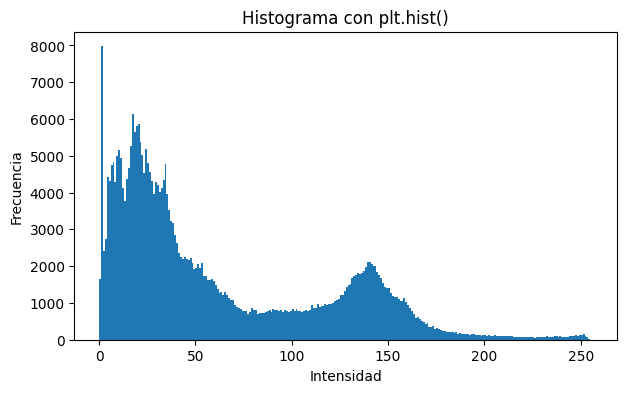

In [15]:
plt.figure(figsize=(7,4))
plt.hist(imagen_gris.ravel(), bins=256, range=[0, 256])
plt.title('Histograma con plt.hist()')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')
plt.show()

## 7. Visualizar imagen y su histograma

En esta parte se muestran juntos la imagen original, la imagen en escala de grises y el histograma. Esto ayuda a comparar la apariencia de la imagen con la forma en la que se distribuyen sus intensidades.

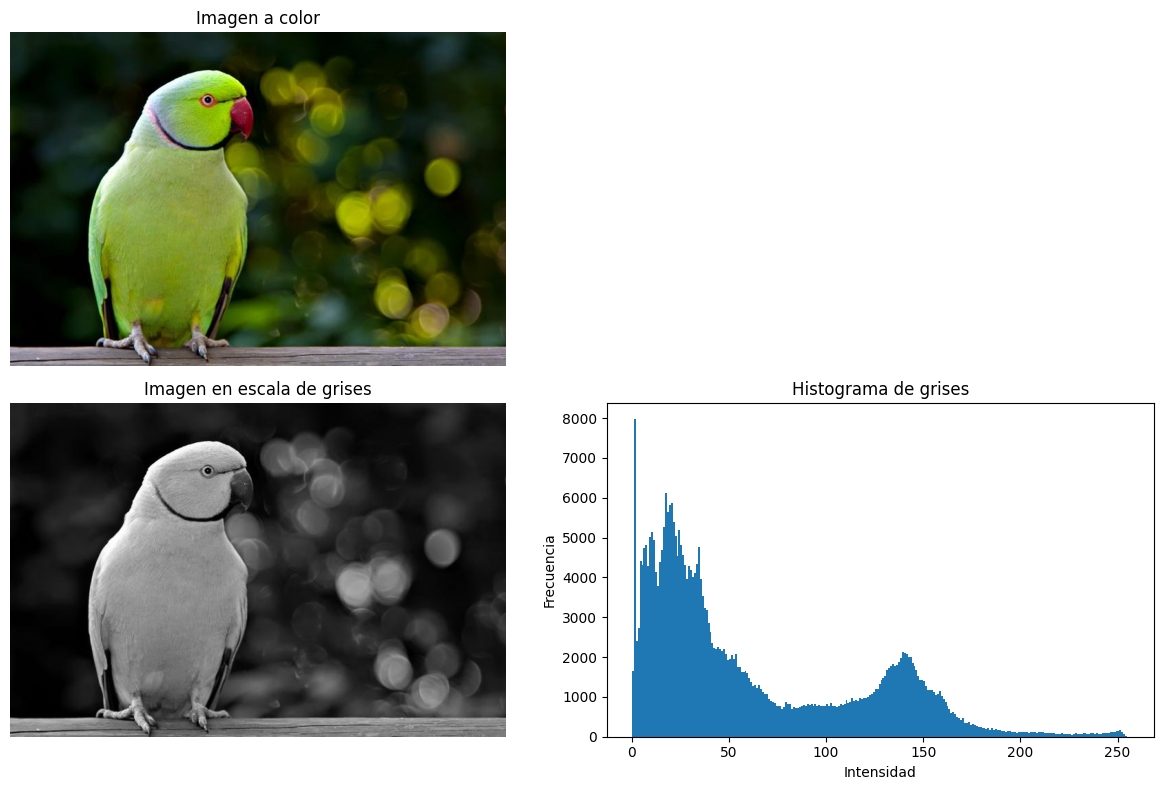

In [16]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(imagen_rgb)
plt.title('Imagen a color')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(imagen_gris, cmap='gray')
plt.title('Imagen en escala de grises')
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(imagen_gris.ravel(), bins=256, range=[0, 256])
plt.title('Histograma de grises')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

## 8. Análisis de resultados

Al analizar el histograma se observa que la mayor cantidad de píxeles está en los tonos oscuros, lo que coincide con el fondo de la imagen. También hay una cantidad de píxeles en tonos medios, que corresponden principalmente al ave y a algunas zonas iluminadas. En general, la imagen presenta un contraste moderado, ya que predominan los tonos oscuros y no se utilizan por igual todos los niveles de intensidad.

## Conclusión

En esta práctica se pudo observar cómo una imagen a color puede transformarse a escala de grises para facilitar su análisis. El histograma fue útil para identificar la distribución de las intensidades y relacionarla con las zonas oscuras y claras de la imagen. Este tipo de procesamiento es importante porque permite extraer información visual de manera más clara y sirve como base para otros métodos de análisis de imágenes.